## Multi Agents

### Theory

In [ ]:
# → Case 1: Reliable Agentic System

# Query
#   ↓
# Router
#   ├── T1 (Tool 1)
#   │     ↓
#   │    FA (Final Answer)
#   │
#   ├── T2 (Tool 2)
#   │     ↓
#   │    FA (Final Answer)
#   │
#   ├── T3 (Tool 3)
#   │     ↓
#   │    FA (Final Answer)
#   │
#   └── Fallback
#         ↓
#        FA (Final Answer)

In [1]:
# → Case 2: Hybrid Agent

# Query (parent)
#   ↓
# Router
#   ├── Graph (Controlled)
#   │     ├── T1 (Tool 1)
#   │     │     ↓
#   │     │    FA (Final Answer)
#   │     │
#   │     ├── T2 (Tool 2)
#   │     │     ↓
#   │     │    FA (Final Answer)
#   │     │
#   │     └── Fallback
#   │           ↓
#   │          FA (Final Answer)
#   │
#   └── Agent (Tx, Ty, ...)
#         (Agent handles everything)

In [2]:
# → Case 3: Multi Agent

# Query
#   ↓
# Router
#   ├── A1 (Agent - Autonomous)
#   │     ├── T1 (Tool 1)
#   │     ├── T2 (Tool 2)
#   │     └── T3 (Tool 3)
#   │
#   ├── A2 (Agent)
#   │     ├── Tx (Tool x)
#   │     └── Ty (Tool y)
#   │
#   └── A3 (Agent)
#         ├── Ta (Tool a)
#         └── Tb (Tool b)

In [3]:
# LLM - Generic Behaviour

# LLM - Persona + Tools = Agent-1
# LLM - Persona + Tools = Agent-2

### Tools

In [4]:
import os
import re
from typing import TypedDict
from datetime import datetime
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langgraph.graph import StateGraph, END
from tavily import TavilyClient

c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'),
                 model='gpt-4o-mini',
                 temperature=0)

llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000013A6029E9D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000013A607B2CD0>, root_client=<openai.OpenAI object at 0x0000013A6029E590>, root_async_client=<openai.AsyncOpenAI object at 0x0000013A607B27D0>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [7]:
@tool
def calculator(expression:str) -> str:
    ' ''Evaluates mathematocal expressions' ''

    print('\n[CALCULATOR TOOL]')

    try:
        return str(eval(expression))
    except :
        return 'Invalid Expression'

### Specialized Agents

In [8]:
math_agent=create_agent(
    model=llm,
    tools=[calculator],

    system_prompt='''You are a math expert.
    You always use the calculator tool to evaluate mathematical expressions.
    Always return the fial answer'''
)

In [9]:
explain_agent=create_agent(
    model=llm,
    tools=[],
    system_prompt='''You ar an AI teacher.
    Explain the AI related concepts in simple and precise language.'''
)

### Wrap the agents as tools

In [13]:
@tool
def math_expert(query: str) -> str:
    """Solve the given math problem"""
    
    print('\n[MATH EXPERT]')

    result = math_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : query}]
        }
    )

    return result['messages'][-1].content

In [14]:
@tool
def explain_expert(query: str) -> str:
    """Explain the AI Concepts simply and precisely"""
    
    print('\n[EXPLAIN EXPERT]')

    result = explain_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : query}]
        }
    )

    return result['messages'][-1].content

### Autonomous Agent

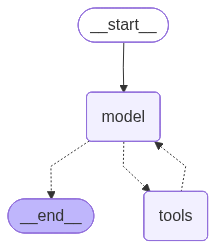

In [21]:
auto_agent = create_agent(
    model = llm,
    tools = [math_expert, explain_expert],
    
    system_prompt='''You are a helpful and intelligent assistant.

You have access to:
    math_expert (for mathematical calculations)
    explain_expert (for explanation of AI related queries)

Instructions:
Decide which tool to be used based upon the query.
You can call multiple tools if needed.
Combine the results from different tools to form the final answer
Do not make unnecessory tool calls.'''
)

auto_agent

### Run the Auto Agent

In [22]:
def agent_call():
    while True:
        query = input('Ask (type exit to quit): ')
        
        if query.lower() in ['exit', 'quit', 'stop', 'end']:
            print('exiting......')
            break
        
        result = auto_agent.invoke(
            {
                'messages': [
                    {'role': 'user', 'content': query}
                ]
            }
        )
        
        print('\nResult:')
        print(result)
            
        print(f"\nFinal Answer: {result['messages'][-1].content}")

In [18]:
agent_call()


[MATH EXPERT]

[CALCULATOR TOOL]

Result:
{'messages': [HumanMessage(content='what is 25*3', additional_kwargs={}, response_metadata={}, id='202a1158-ec6f-46df-b140-56d18ffe644b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 150, 'total_tokens': 167, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c93645df76', 'id': 'chatcmpl-DQ4nzojkv3LvmYQrLQjX40kuY5yLr', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d4ca4-d5f3-7663-abd6-dafe91505757-0', tool_calls=[{'name': 'math_expert', 'args': {'query': '25*3'}, 'id': 'call_f1sWsU8J6wHPEmiDPmKndWOD', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'

In [25]:
agent_call()


[EXPLAIN EXPERT]

Result:
{'messages': [HumanMessage(content='what is multi agent in AI', additional_kwargs={}, response_metadata={}, id='5c6a22f3-455c-4e45-9d09-f71ce81fe106'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 150, 'total_tokens': 174, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f8f4a36a85', 'id': 'chatcmpl-DQ4yTYShHGdCIijlSMQNJujMUNjM3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d4cae-c57c-7891-afa8-055b1546b88f-0', tool_calls=[{'name': 'explain_expert', 'args': {'query': 'What is a multi-agent system in AI?'}, 'id': 'call_H1LX7M1ucfPLgXYkgCyXlAGP', 'type': 'tool_call'}], invalid_t

In [24]:
agent_call()


Result:
{'messages': [HumanMessage(content='what is the capital of India?', additional_kwargs={}, response_metadata={}, id='0e1000a5-c7ce-426f-a63f-595523c734f4'), AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 151, 'total_tokens': 160, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f8f4a36a85', 'id': 'chatcmpl-DQ4yBrOJxl3qQ8C2Ou9pY5rs77SB0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d4cae-84d3-7bf0-98c5-d8d7fe6b1d99-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 151, 'output_tokens': 9, 'total_tokens': 160, 'input_token_details': {'audio': 0, 'ca

In [26]:
agent_call()


[MATH EXPERT]

[EXPLAIN EXPERT]

[CALCULATOR TOOL]

Result:
{'messages': [HumanMessage(content='what is 2345/12? What are the important conceps to be covered while learning AI Agents?', additional_kwargs={}, response_metadata={}, id='11af117e-254c-4aa1-87a8-7d3d61d30451'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 166, 'total_tokens': 221, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f8f4a36a85', 'id': 'chatcmpl-DQ4zkEYDcCOVhAP2R2co07fe4yi2c', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d4caf-fcbc-7533-9dae-a1a3c61270ac-0', tool_calls=[{'name': 'math_expert', 'args': {'query': '2345/12'}, 'id': 

In [27]:
agent_call()


[MATH EXPERT]

[MATH EXPERT]

[EXPLAIN EXPERT]

[CALCULATOR TOOL]

[CALCULATOR TOOL]

Result:
{'messages': [HumanMessage(content='what is 234%5 and 345*2? Explain Agentic AI? What is the capital of Andhra Pradesh?', additional_kwargs={}, response_metadata={}, id='740ee731-5331-40d2-8a91-732c638e73b5'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 169, 'total_tokens': 240, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f8f4a36a85', 'id': 'chatcmpl-DQ52xKLcYgoq5mnf8s5KHp3cHiD6D', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d4cb3-0627-7992-bb10-ec4a5f24ac5f-0', tool_calls=[{'name': 'math_expert', 'args'